In [94]:
!pip install pyts

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.5 MB 3.3 MB/s eta 0:00:01
   ---- ----------------------------------- 0.3/2.5 MB 3.1 MB/s eta 0:00:01
   ------ --------------------------------- 0.4/2.5 MB 3.4 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 4.3 MB/s eta 0:00:01
   -------------- ------------------------- 1.0/2.5 MB 4.3 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.5 MB 4.5 MB/s eta 0:00:01
   ------------------------- -------------- 1.6/2.5 MB 4.8 MB/s eta 0:00:01
   ----------------------------- ---------- 1.9/2.5 MB 5.2 MB/s eta 0:00:01
   ---------------------------------- ----- 2.2/2.5 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  2.5/2.5 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 5.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -- --------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\lenovo\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyts.image import RecurrencePlot
import os

In [2]:
df = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_merged_data.csv")

In [28]:
df.head()

,Unnamed: 0,user_id,emotion,timestamp,x_0,y_0,z_0,x_1,y_1,z_1,...,z_9,x_10,y_10,z_10,x_11,y_11,z_11,x_12,y_12,z_12
0,0,U03,E01,0.00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.267099,-1.267099,2.239453,NaN,NaN,NaN,NaN,NaN,NaN
1,1,U03,E01,0.07,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,U03,E01,0.09,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,U03,E01,0.10,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,U03,E01,0.10,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer

spf = 0.1  # reciprocal of frames per second
image_size=128
num_sensors = 13
df["timestamp"] = df["timestamp"].round(decimals=2)

X=[]
Y=[]
for (user_id, emotion), group_data in df.groupby(["user_id","emotion"]):
    #print(f"User ID: {user_id}, Emotion: {emotion}")

    sample_rps = np.zeros((num_sensors*3, image_size, image_size), dtype=np.float64)
    for s_id in range(num_sensors):
        sensor_data = group_data[["timestamp",f"x_{s_id}",f"y_{s_id}",f"z_{s_id}"]]
        sensor_data = sensor_data.dropna()
        #print(f"Sensor ID: {s_id}, Number of Valid Samples: {len(sensor_data)}")

        # Avoid operations on empty dataframes, 10 samples is an arbitrary threshold
        if len(sensor_data) < 10:
            continue
        
        start, end = sensor_data["timestamp"].min(), sensor_data["timestamp"].max()
        #print(f"Timestamp Range: {start} to {end}")
        
        # Train a model to interpolate the sensor data at regular intervals
        timestamps = sensor_data["timestamp"].values - start
        x_train = timestamps.reshape(-1, 1)
        y_train = sensor_data[[f"x_{s_id}", f"y_{s_id}", f"z_{s_id}"]].values
        model = make_pipeline(SplineTransformer(n_knots=4, degree=3), Ridge(alpha=1e-3))
        model.fit(x_train, y_train)

        # Interpolate at regular intervals and create recurrence plots
        interp_timestamps = np.arange(0, end - start, step=spf).reshape(-1, 1)
        interp_sensor_data = model.predict(interp_timestamps)

        os.makedirs(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}", exist_ok=True)
        x_interp = interp_sensor_data[:, 0].reshape(1, -1)
        y_interp = interp_sensor_data[:, 1].reshape(1, -1)
        z_interp = interp_sensor_data[:, 2].reshape(1, -1)
        rp = RecurrencePlot(threshold="point", percentage=20)
        x_rp_image = rp.fit_transform(x_interp)[0]
        y_rp_image = rp.fit_transform(y_interp)[0]
        z_rp_image = rp.fit_transform(z_interp)[0]

        x_rp_image = cv2.resize(x_rp_image, (image_size, image_size))
        y_rp_image = cv2.resize(y_rp_image, (image_size, image_size))
        z_rp_image = cv2.resize(z_rp_image, (image_size, image_size))

        plt.imsave(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}/sensor_{s_id}_x.png", x_rp_image, cmap='binary', origin='lower')
        plt.imsave(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}/sensor_{s_id}_y.png", y_rp_image, cmap='binary', origin='lower')
        plt.imsave(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}/sensor_{s_id}_z.png", z_rp_image, cmap='binary', origin='lower')
        sample_rps[3*s_id] = x_rp_image
        sample_rps[3*s_id + 1] = y_rp_image
        sample_rps[3*s_id + 2] = z_rp_image
    np.savez(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}/Recurrence_Plots.npz", rps=sample_rps)
    X.append(sample_rps)
    Y.append(emotion)
    
X = np.stack(X)
Y = np.array(Y)

In [79]:
np.savez("E:/CoDaS Project/Radar/C3_RP_dataset.npz", data=X, labels=Y)

Text(0, 0.5, 'Time')

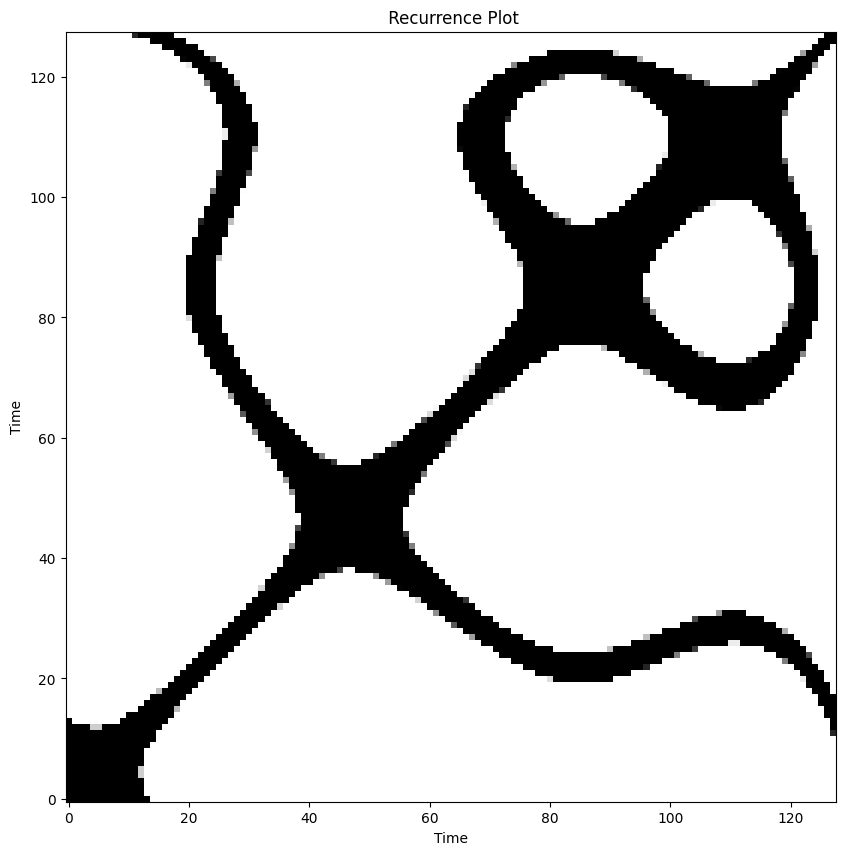

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(12, 10))
axs.imshow(cv2.resize(y_rp_image, (128, 128)), cmap='binary', origin='lower')
axs.set_title(f' Recurrence Plot')
axs.set_xlabel('Time')
axs.set_ylabel('Time')

In [5]:
time_length = 6
time = np.round(group_data["timestamp"].to_numpy(),decimals=2)

In [6]:
time_length = 6
cursor= min(time) # Starting point
segments = []  # To store the segmented data
while True:
    # Process the current portion
    positions=np.where((time >= cursor) & (time <= cursor + time_length))[0]
    segments.append((positions[0], positions[-1]))
    if cursor + time_length >= max(time) or len(positions) == 0:
        break
    cursor = time[positions[-1]+1]  # Move cursor to the next segment
    
print(segments)

[(0, 471), (472, 742), (743, 1159), (1160, 1487), (1488, 1913), (1914, 2213), (2214, 2553), (2554, 2781), (2782, 2880), (2881, 3014), (3015, 3316), (3317, 3449), (3450, 3516), (3517, 3558), (3559, 3682), (3683, 3793), (3794, 3930), (3931, 4019), (4020, 4083), (4084, 4186)]


In [7]:
data_segment=group_data.iloc[segments[0][0]:segments[0][1]+1]

In [15]:
sensor_segment=data_segment[["timestamp","x_0","y_0","z_0"]].dropna()

In [28]:
signal=sensor_segment.to_numpy()[:,1].reshape(1, -1)

Text(0, 0.5, 'Time')

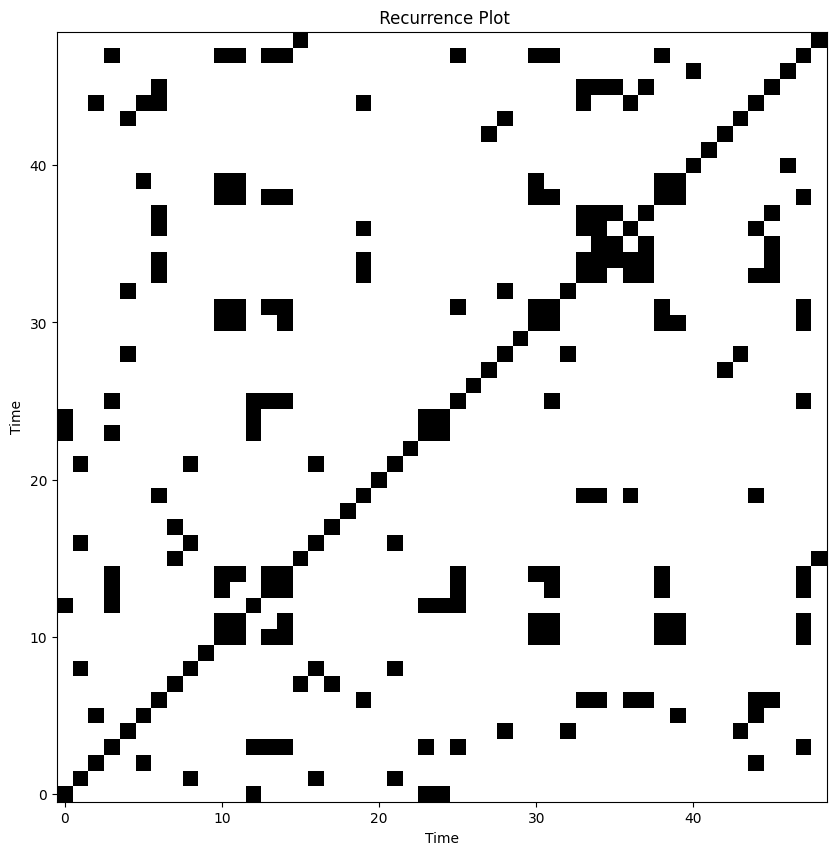

In [31]:
rp = RecurrencePlot(threshold='point', percentage=10)

fig, axs = plt.subplots(1, 1, figsize=(12, 10))
# Compute and plot recurrence plot
rp_image = rp.fit_transform(signal)[0]
axs.imshow(rp_image, cmap='binary', origin='lower')
axs.set_title(f' Recurrence Plot')
axs.set_xlabel('Time')
axs.set_ylabel('Time')